<a id="top"></a>
# Chapter 6 — Constraints, restraints and potentials

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 6 of 10

[◀ 5 X-ray data and the Bragg profile](RMCProfile_05_Xray_and_Bragg.ipynb) · [Contents of the book](README.md) · [7 Corrections: resolution, Q-damping and nano-size ▶](RMCProfile_07_Corrections.ipynb)

**In this chapter**

- [§23 Why data are not enough](#sec-23)
- [§24 Closest approach: `MINIMUM_DISTANCES`](#sec-24)
- [§25 Distance windows: keeping the neighbours you start with](#sec-25)
- [§26 Interatomic potentials and coordination constraints](#sec-26)
- [§27 Bond valence sums](#sec-27)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 14}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 6")
t_chapter_start = time.time()

rmcprofile-skill 0.3.0 | numpy 2.5.2 | RMCProfile package: windows build | chapter 6


<a id="sec-23"></a>

## 23. Why data are not enough

A pair distribution function constrains distances, not chemistry: a fit that reproduces
$G(r)$ can still put two chlorines where a sodium belongs, break a tetrahedron, or let an
atom drift through a wall of neighbours. RMCProfile therefore carries constraints
(hard: the move is impossible) and restraints (soft: the move is penalised) — manual §2.5–2.9.
This chapter exercises each of them on the synthetic NaCl set of chapter 4: a short run per
keyword block, and a measurement on the box the program saved. Every run starts from the
ideal lattice and lasts six seconds; with only a real-space data set RMCProfile makes
tens of thousands of moves in that time.

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3), title="NaCl 3x3x3")
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / cfg.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)
G_data = G_truth + rng.normal(0, 0.003, G_truth.shape)

def run_with(tag, extra_blocks=(), min_dist=None, max_move=0.1, minutes=0.1, weight=0.01):
    '''Write a fresh synthetic set with the given blocks, run RMCProfile, return the saved box and the chi2 rows.'''
    work = os.path.join(WORK, tag)
    rt.write_input_set("c", work, cfg, gr=(r, G_data), weights=(weight, 0.01),
                       min_dist=min_dist or {"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0}, max_move=max_move,
                       time_limit_min=minutes, extra_blocks=list(extra_blocks), title=tag)
    res = rt.run_rmcprofile("c", work, PKG, timeout_min=3)
    hist = rt.read_chi2_history(os.path.join(work, "c.chi2"))
    box = rt.read_rmc6f(os.path.join(work, "c.rmc6f"))
    print(f"{tag}: rc={res.returncode}, {hist['m_generated'][-1]} moves, chi2 {hist['chi2'][0]:.4g} -> {hist['chi2'][-1]:.4g}")
    return box, hist, work

def first_shell(box):
    d = rt._min_image_distances(box)
    ia, ib = np.where(box.atoms == "Na")[0], np.where(box.atoms == "Cl")[0]
    return np.sort(d[np.ix_(ia, ib)], axis=1)[:, :6]

print("ready:", cfg.n_atoms(), "atoms; RMCProfile package:", "found" if PKG else "not set")

ready: 216 atoms; RMCProfile package: found


<a id="sec-24"></a>

## 24. Closest approach: `MINIMUM_DISTANCES`

One number per pair (in the order AA AB AC BB BC CC…) below which no two atoms may come. It
is the constraint every RMC run carries; RMCProfile's own message when it stops early —
"Check the MINIMUM_DISTANCES section" — is about the *count* of numbers, which the checker
verifies before the run. Raise the Na–Cl minimum above the inner edge of the thermal shell
and the refined box cannot reach the data's peak from below.

free: rc=0, 94089 moves, chi2 6.542e+04 -> 2.558


tight: rc=0, 124301 moves, chi2 6.542e+04 -> 212.7
Na–Cl first shell: free run 2.615–3.044 Å, tight run 2.750–2.947 Å


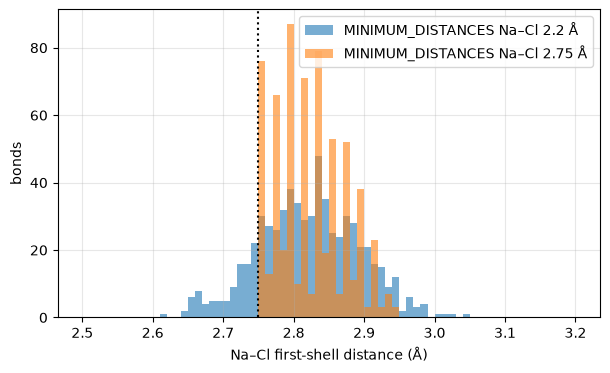

[PASS] the free run reaches below 2.75 Å, the tight run never does
[PASS] the tight run fits worse (its chi2 stays higher) — 212.7 vs 2.558


In [3]:
if not skip_without_package("the constraint runs of this chapter"):
    box_free, h_free, _ = run_with("free", min_dist={"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})
    box_tight, h_tight, _ = run_with("tight", min_dist={"Na-Na": 3.0, "Na-Cl": 2.75, "Cl-Cl": 3.0})
    s_free, s_tight = first_shell(box_free), first_shell(box_tight)
    print(f"Na–Cl first shell: free run {s_free.min():.3f}–{s_free.max():.3f} Å, tight run {s_tight.min():.3f}–{s_tight.max():.3f} Å")
    fig, ax = plt.subplots()
    ax.hist(s_free.ravel(), bins=np.arange(2.5, 3.2, 0.01), alpha=0.6, label="MINIMUM_DISTANCES Na–Cl 2.2 Å")
    ax.hist(s_tight.ravel(), bins=np.arange(2.5, 3.2, 0.01), alpha=0.6, label="MINIMUM_DISTANCES Na–Cl 2.75 Å")
    ax.axvline(2.75, color="k", ls=":")
    ax.set_xlabel("Na–Cl first-shell distance (Å)"); ax.set_ylabel("bonds"); ax.legend()
    show(fig)
    caption("The Na–Cl first-shell distances of two refined boxes: with the closest approach "
            "at 2.2 Å the thermal shell is reproduced on both sides of 2.82 Å; with it at 2.75 Å "
            "(dotted) no bond can be shorter, and the distribution is cut off there.")
    check("the free run reaches below 2.75 Å, the tight run never does", s_free.min() < 2.75 <= s_tight.min())
    check("the tight run fits worse (its chi2 stays higher)", h_tight["chi2"][-1] > h_free["chi2"][-1],
          f"{h_tight['chi2'][-1]:.4g} vs {h_free['chi2'][-1]:.4g}")

<a id="sec-25"></a>

## 25. Distance windows: keeping the neighbours you start with

`DISTANCE_WINDOW ::` with `MNDIST`/`MXDIST` (one value per pair, zero for "no window")
does two things (manual §2.5): it bounds a pair's distance from *both* sides, and it fixes
the neighbour list when the run starts — every Na keeps its own six Cl, so the topology of a
molecule or a framework survives however far the atoms wander. The program writes the list
to `.neigh`; delete it whenever the configuration changes (the checker warns).

In [4]:
if not skip_without_package("the distance-window run"):
    dw = rt.DatBlock("DISTANCE_WINDOW", "", [("MNDIST", "0 2.60 0"), ("MXDIST", "0 3.05 0")])
    box_dw, h_dw, work_dw = run_with("window", extra_blocks=[dw], max_move=0.2)
    box_nodw, h_nodw, _ = run_with("nowindow", max_move=0.2)
    s_dw, s_nodw = first_shell(box_dw), first_shell(box_nodw)
    print(f"first shell: with window {s_dw.min():.3f}–{s_dw.max():.3f} Å; without {s_nodw.min():.3f}–{s_nodw.max():.3f} Å")
    print("neighbour files written:", sorted(f for f in os.listdir(work_dw) if f.endswith((".neigh", ".neighlog"))))
    check("with the window every Na–Cl first-shell distance stays inside [2.60, 3.05] Å", s_dw.min() >= 2.60 and s_dw.max() <= 3.05)
    print("(at 0.2 Å moves the data alone keep the shell inside the window — the window's real job shows at 0.5 Å moves, exercise 6.1)")
    check("RMCProfile wrote its .neigh list", "c.neigh" in os.listdir(work_dw))
    findings = rt.check_input_set("c", work_dw)
    check("the checker now warns about the neighbour files", "stale-neighbour-files" in [f.code for f in findings])

window: rc=0, 84877 moves, chi2 6.542e+04 -> 4.291


nowindow: rc=0, 72230 moves, chi2 6.542e+04 -> 3.472
first shell: with window 2.622–3.035 Å; without 2.618–3.092 Å
neighbour files written: ['c.neigh', 'c.neighlog']
[PASS] with the window every Na–Cl first-shell distance stays inside [2.60, 3.05] Å
(at 0.2 Å moves the data alone keep the shell inside the window — the window's real job shows at 0.5 Å moves, exercise 6.1)
[PASS] RMCProfile wrote its .neigh list
[PASS] the checker now warns about the neighbour files


<a id="sec-26"></a>

## 26. Interatomic potentials and coordination constraints

`POTENTIALS ::` adds a harmonic bond term, $\tfrac12 k (d - d_0)^2$ per `STRETCH` pair
within `STRETCH_SEARCH` of $d_0$, whose Boltzmann factor at `TEMPERATURE` enters the
acceptance rule (manual §2.6; chapter 2 §6 has the rule). A stiff potential narrows the
Na–Cl shell whatever the data say. `FIXED_COORDINATION_CONSTRAINTS ::` asks that a
fraction of the atoms of one type keep a given number of neighbours of another within a
distance range (`CSTR1 :: type neighbour rmin rmax CN fraction weight`); RMCProfile reports
the fraction achieved at every print.

In [5]:
if not skip_without_package("the potential and coordination runs"):
    pot = rt.DatBlock("POTENTIALS", "", [("STRETCH", "Na Cl 40.0 eV 2.82 Ang"), ("STRETCH_SEARCH", "10%"), ("TEMPERATURE", "300 K")])
    box_pot, h_pot, _ = run_with("potential", extra_blocks=[pot], max_move=0.1)
    box_ref, h_ref, _ = run_with("reference", max_move=0.1)
    w_pot, w_ref = first_shell(box_pot).std(), first_shell(box_ref).std()
    print(f"Na–Cl first-shell spread: with a 40 eV/Å² stretch potential {w_pot:.4f} Å, without {w_ref:.4f} Å")
    check("a stiff bond potential narrows the first shell", w_pot < w_ref)

    cn = rt.DatBlock("FIXED_COORDINATION_CONSTRAINTS", "1", [("CSTR1", "1 2 2.0 3.2 6 1.0 0.00001")])
    box_cn, h_cn, work_cn = run_with("coordination", extra_blocks=[cn], max_move=0.3)
    counts, hist = rt.coordination(box_cn, "Na", "Cl", rmax=3.2)
    with open(os.path.join(work_cn, "run.log"), encoding="utf-8", errors="replace") as f:
        frac_lines = [ln.strip() for ln in f if "Coordination constraint" in ln]
    print(frac_lines[-1] if frac_lines else "(no constraint report)")
    print("Na coordination after 0.3 Å moves under the constraint:", hist)
    check("RMCProfile reports the coordination constraint at 100 %", frac_lines and "100.00%" in frac_lines[-1])
    check("every Na still has six Cl within 3.2 Å", hist == {6: 108}, str(hist))

potential: rc=0, 62173 moves, chi2 6.542e+04 -> 23.31


reference: rc=0, 98513 moves, chi2 6.542e+04 -> 2.845
Na–Cl first-shell spread: with a 40 eV/Å² stretch potential 0.0561 Å, without 0.0723 Å
[PASS] a stiff bond potential narrows the first shell


coordination: rc=0, 87242 moves, chi2 6.525e+04 -> 4.248
Coordination constraint  1: Fraction=100.00%; target=100.00%
Na coordination after 0.3 Å moves under the constraint: {6: 108}
[PASS] RMCProfile reports the coordination constraint at 100 %
[PASS] every Na still has six Cl within 3.2 Å — {6: 108}


<a id="sec-27"></a>

## 27. Bond valence sums

The bond valence sum $V_i = \sum_j \exp[(R_0 - d_{ij})/b]$ (Brese & O'Keeffe 1991) turns a
coordination shell into a chemical check: it should equal the ion's oxidation state.
RMCProfile's `BVS ::` block (manual §2.7, App. C) restrains the fit toward the nominal
valences; the toolkit's `bond_valence_sum` computes the same quantity on any box, so the
restraint's effect can be read off the result. For Na–Cl, $R_0 = 2.15$ Å and $b = 0.37$ Å
give $V_{\rm Na} \approx 1$ on the ideal lattice.

ideal lattice: BVS(Na) = 0.981
[PASS] Na is monovalent by bond valence on the ideal lattice — 0.981


bvs: rc=0, 93580 moves, chi2 6.542e+04 -> 3.389
refined box under the BVS restraint: BVS(Na) = 0.995 ± 0.060; chi2 columns ['m_accepted', 'm_generated', 'm_tested', 'chi2', 'Expt_1', 'BVS_Chi2', 'BVS_1', 'BVS_2']


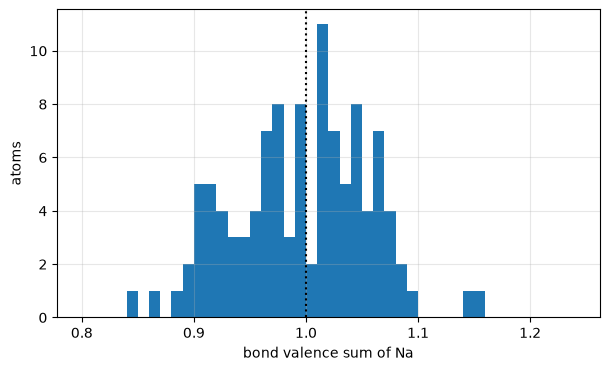

[PASS] RMCProfile reported a BVS term in its chi2 rows
[PASS] the refined Na atoms are monovalent on average (0.9–1.1) — 0.995


In [6]:
bvs_ideal = rt.bond_valence_sum(cfg, "Na", "Cl", r0=2.15, b=0.37, cutoff=3.2)
print(f"ideal lattice: BVS(Na) = {bvs_ideal.mean():.3f}")
check("Na is monovalent by bond valence on the ideal lattice", abs(bvs_ideal.mean() - 1.0) < 0.05, f"{bvs_ideal.mean():.3f}")
if not skip_without_package("the BVS run"):
    bvs = rt.DatBlock("BVS", "", [("ATOM", "Na Cl"), ("OXID", "1 -1"), ("WEIGHTS", "0.055 0.055"), ("RIJ", "0 2.15"),
                                  ("BVAL", "0 0.37"), ("CUTOFF", "0 3.2"), ("SAVE", "400000"), ("UPDATE", "200000")])
    box_bvs, h_bvs, work_bvs = run_with("bvs", extra_blocks=[bvs], max_move=0.1)
    v = rt.bond_valence_sum(box_bvs, "Na", "Cl", r0=2.15, b=0.37, cutoff=3.2)
    print(f"refined box under the BVS restraint: BVS(Na) = {v.mean():.3f} ± {v.std():.3f}; chi2 columns {list(h_bvs)}")
    fig, ax = plt.subplots()
    ax.hist(v, bins=np.arange(0.8, 1.25, 0.01))
    ax.axvline(1.0, color="k", ls=":"); ax.set_xlabel("bond valence sum of Na"); ax.set_ylabel("atoms")
    show(fig)
    caption("Bond valence sums of the 108 Na atoms in the box refined under RMCProfile's BVS "
            "restraint, computed with the toolkit's own calculator (R₀ = 2.15 Å, b = 0.37 Å, "
            "cutoff 3.2 Å): centred on +1, the nominal valence.")
    check("RMCProfile reported a BVS term in its chi2 rows", any(k.startswith("BVS") for k in h_bvs))
    check("the refined Na atoms are monovalent on average (0.9–1.1)", 0.9 < v.mean() < 1.1, f"{v.mean():.3f}")

### Exercises for chapter 6

**6.1** Set `MAXIMUM_MOVES` to 0.5 Å for both types and run 0.1 minutes without any window.
Does the box still have six Cl around every Na? Then add the window of §25 and compare.

**6.2** Compute the bond valence sum of Cl from its Na neighbours on the ideal lattice (the
same $R_0$ and $b$). Why must it come out as −1 in magnitude, and does it?

In [7]:
if not skip_without_package("exercise 6.1"):
    # 6.1 — with 0.5 A moves atoms hop between shells; the window pins the neighbour list
    b_wild, _, _ = run_with("wild", max_move=0.5)
    _, hist_wild = rt.coordination(b_wild, "Na", "Cl", rmax=3.2)
    b_wild_dw, _, _ = run_with("wild_window", extra_blocks=[rt.DatBlock("DISTANCE_WINDOW", "", [("MNDIST", "0 2.60 0"), ("MXDIST", "0 3.05 0")])], max_move=0.5)
    _, hist_wild_dw = rt.coordination(b_wild_dw, "Na", "Cl", rmax=3.2)
    print("0.5 Å moves without window:", hist_wild, "| with window:", hist_wild_dw)
    check("6.1 the window keeps six neighbours where free 0.5 Å moves do not", hist_wild_dw == {6: 108} and hist_wild != {6: 108})

# 6.2 — the same six Na-Cl bonds are seen from the Cl side; by symmetry the sum is the same number, +1 in
#       magnitude for the Cl anion (the sign is the oxidation state's convention, not the sum's).
bvs_cl = rt.bond_valence_sum(cfg, "Cl", "Na", r0=2.15, b=0.37, cutoff=3.2)
check("6.2 the Cl bond valence sum equals the Na one on the ideal lattice", abs(bvs_cl.mean() - bvs_ideal.mean()) < 1e-9, f"{bvs_cl.mean():.3f}")

wild: rc=0, 81934 moves, chi2 6.542e+04 -> 5.803


wild_window: rc=0, 96251 moves, chi2 6.542e+04 -> 6.714
0.5 Å moves without window: {3: 1, 6: 107} | with window: {6: 108}
[PASS] 6.1 the window keeps six neighbours where free 0.5 Å moves do not
[PASS] 6.2 the Cl bond valence sum equals the Na one on the ideal lattice — 0.981


True

In [8]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 6 — checks passed : {_CHECKS['pass']}")
print(f"chapter 6 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 6 — checks passed : 13
chapter 6 — checks failed : 0
wall time                 : 65 s
Every quantitative claim in this notebook was verified in this run.
